In [1]:
import cv2
import numpy as np

## Video original con la marca de inicio(A) y la marca final(B)

Obtención de los FPS del video

In [2]:
cap = cv2.VideoCapture('video.mp4')
cap.get(cv2.CAP_PROP_FPS)

30.181699930897118

In [24]:
cap = cv2.VideoCapture('video.mp4')

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)  # Reinicia al inicio
        continue

    cv2.line(frame, (355, 145), (410, 140), (0, 255, 0), 2)
    cv2.putText(frame, 'A', (355, 135), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
    cv2.line(frame, (355, 471), (490, 471), (0, 255, 0), 2)
    cv2.putText(frame, 'B', (355, 461), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
    cv2.imshow('Video', frame)

    if cv2.waitKey(25) & 0xFF == 27:  # ESC
        break

cap.release()
cv2.destroyAllWindows()

## ROI del video

In [5]:
cap = cv2.VideoCapture('video.mp4')
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
        continue

    roi = frame[145:471, 355:461]  # [y1:y2, x1:x2]

    cv2.imshow('Video', roi)

    if cv2.waitKey(25) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

## Conversión a escala de grises y ajuste de parametros

El siguiente bloque de código muestra el video junto a varios sliders con los que se pueden modificar el valor de:
- Grismin
- Grismax
- Contraste
- Brillo
- Gamma

Se utilizo para encontrar los valores ideales para cada uno

In [109]:
cap = cv2.VideoCapture('video.mp4')

cv2.namedWindow('Video')
cv2.createTrackbar('Gris Min',  'Video', 0,   254, lambda x: None)
cv2.createTrackbar('Gris Max',  'Video', 255, 255, lambda x: None)
cv2.createTrackbar('Contraste', 'Video', 10,  30,  lambda x: None)  # dividir entre 10
cv2.createTrackbar('Brillo',    'Video', 100, 200, lambda x: None)  # restar 100
cv2.createTrackbar('Gamma',     'Video', 10,  30,  lambda x: None)  # dividir entre 10

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
        continue

    gris_min  = cv2.getTrackbarPos('Gris Min',  'Video')
    gris_max  = cv2.getTrackbarPos('Gris Max',  'Video')
    contraste = cv2.getTrackbarPos('Contraste', 'Video') / 10
    brillo    = cv2.getTrackbarPos('Brillo',    'Video') - 100
    gamma     = cv2.getTrackbarPos('Gamma',     'Video') / 10

    gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Min/Max
    if gris_max > gris_min:
        gris = np.clip((gris - gris_min) * (255 / (gris_max - gris_min)), 0, 255).astype(np.uint8)

    # Contraste y brillo
    gris = cv2.convertScaleAbs(gris, alpha=contraste, beta=brillo)

    # Gamma
    if gamma > 0:
        tabla_gamma = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)
        gris = cv2.LUT(gris, tabla_gamma)

    cv2.imshow('Video', gris)

    if cv2.waitKey(25) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

Los valores ideales encontrados fueron 
- Grismin: 180
- Grismax: 255
- Contraste: 12
- Brillo: 0
- Gamma: 30

Adicionalmente se utilizo la función `cv2.createBackgroundSubtractorMOG2()` y se aplico el ROI para finalmente obtener la mascara con un ruido mínimo

In [96]:
cap = cv2.VideoCapture('video.mp4')
sustractor = cv2.createBackgroundSubtractorMOG2(history=500, varThreshold=50, detectShadows=False)
kernel = np.ones((5, 5), np.uint8)

gris_min  = 180
gris_max  = 255
contraste = 1.2
brillo    = 0
gamma     = 3.0
tabla_gamma = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
        continue

    gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gris = np.clip((gris - gris_min) * (255 / (gris_max - gris_min)), 0, 255).astype(np.uint8)
    gris = cv2.convertScaleAbs(gris, alpha=contraste, beta=brillo)
    gris = cv2.LUT(gris, tabla_gamma)

    mascara = sustractor.apply(gris)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel)

    mascara = mascara[145:471, 355:461]  # [y1:y2, x1:x2]

    cv2.imshow('Mascara', mascara)

    if cv2.waitKey(25) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

## Substracción de fondo

In [8]:
cap = cv2.VideoCapture('video.mp4')
sustractor = cv2.createBackgroundSubtractorMOG2(history=500, varThreshold=50, detectShadows=False)
kernel = np.ones((5, 5), np.uint8)

gris_min  = 180
gris_max  = 255
contraste = 1.2
brillo    = 0
gamma     = 3.0
tabla_gamma = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
        continue

    gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gris = np.clip((gris - gris_min) * (255 / (gris_max - gris_min)), 0, 255).astype(np.uint8)
    gris = cv2.convertScaleAbs(gris, alpha=contraste, beta=brillo)
    gris = cv2.LUT(gris, tabla_gamma)

    mascara = sustractor.apply(gris)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel)

    mascara = mascara[145:471, 355:461]  # [y1:y2, x1:x2]

    cv2.imshow('Mascara', mascara)

    if cv2.waitKey(25) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

## Se aplica la mascara al video original en el ROI

In [107]:
cap = cv2.VideoCapture('video.mp4')
sustractor = cv2.createBackgroundSubtractorMOG2(history=500, varThreshold=50, detectShadows=False)
kernel = np.ones((5, 5), np.uint8)

gris_min  = 180
gris_max  = 255
contraste = 1.2
brillo    = 0
gamma     = 3.0
tabla_gamma = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
        continue

    gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gris = np.clip((gris - gris_min) * (255 / (gris_max - gris_min)), 0, 255).astype(np.uint8)
    gris = cv2.convertScaleAbs(gris, alpha=contraste, beta=brillo)
    gris = cv2.LUT(gris, tabla_gamma)

    mascara = sustractor.apply(gris)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel)
    mascara = mascara[145:471, 355:461]

    roi = frame[145:471, 355:461]  # ROI del video original en color

    resultado = cv2.bitwise_and(roi, roi, mask=mascara)

    cv2.imshow('Resultado', resultado)

    if cv2.waitKey(25) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

## Se aplica dilatación a la mascara y se aplica al video original en el ROI

In [108]:
cap = cv2.VideoCapture('video.mp4')
sustractor = cv2.createBackgroundSubtractorMOG2(history=500, varThreshold=50, detectShadows=False)
kernel = np.ones((5, 5), np.uint8)
kernel_dilate = np.ones((15, 15), np.uint8)  # ajusta el tamaño para más o menos expansión

gris_min  = 180
gris_max  = 255
contraste = 1.2
brillo    = 0
gamma     = 3.0
tabla_gamma = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
        continue

    gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gris = np.clip((gris - gris_min) * (255 / (gris_max - gris_min)), 0, 255).astype(np.uint8)
    gris = cv2.convertScaleAbs(gris, alpha=contraste, beta=brillo)
    gris = cv2.LUT(gris, tabla_gamma)

    mascara = sustractor.apply(gris)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel)
    mascara = cv2.dilate(mascara, kernel_dilate, iterations=1)  # expande zonas blancas

    roi = frame[145:471, 355:461]  # ROI del video original en color

    mascara = mascara[145:471, 355:461]
    resultado = cv2.bitwise_and(roi, roi, mask=mascara)
    cv2.imshow('Resultado', resultado)

    if cv2.waitKey(25) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

## Obtención de contorno y centroide

In [3]:
cap = cv2.VideoCapture('video.mp4')
sustractor = cv2.createBackgroundSubtractorMOG2(history=500, varThreshold=50, detectShadows=False)
kernel = np.ones((5, 5), np.uint8)
kernel_dilate = np.ones((15, 15), np.uint8)

gris_min  = 180
gris_max  = 255
contraste = 1.2
brillo    = 0
gamma     = 3.0
tabla_gamma = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
        continue

    gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gris = np.clip((gris - gris_min) * (255 / (gris_max - gris_min)), 0, 255).astype(np.uint8)
    gris = cv2.convertScaleAbs(gris, alpha=contraste, beta=brillo)
    gris = cv2.LUT(gris, tabla_gamma)

    mascara = sustractor.apply(gris)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel)
    mascara = cv2.dilate(mascara, kernel_dilate, iterations=1)
    mascara = mascara[145:471, 355:461]

    contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    visualizacion = cv2.cvtColor(mascara, cv2.COLOR_GRAY2BGR)

    if len(contornos) >= 2:
        # Toma los 2 contornos más grandes y los une
        dos_mayores = sorted(contornos, key=cv2.contourArea, reverse=True)[:2]
        puntos_unidos = np.vstack(dos_mayores)
        contorno_final = cv2.convexHull(puntos_unidos)

    elif len(contornos) == 1:
        contorno_final = cv2.convexHull(contornos[0])

    else:
        contorno_final = None

    if contorno_final is not None:
        cv2.drawContours(visualizacion, [contorno_final], -1, (0, 255, 0), 2)

        M = cv2.moments(contorno_final)
        if M['m00'] != 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])
            cv2.circle(visualizacion, (cx, cy), 5, (0, 0, 255), -1)
            cv2.putText(visualizacion, f'({cx},{cy})', (cx + 8, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

    cv2.imshow('Contorno y Centroide', visualizacion)

    if cv2.waitKey(25) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

## Análisis cinematico y resultados

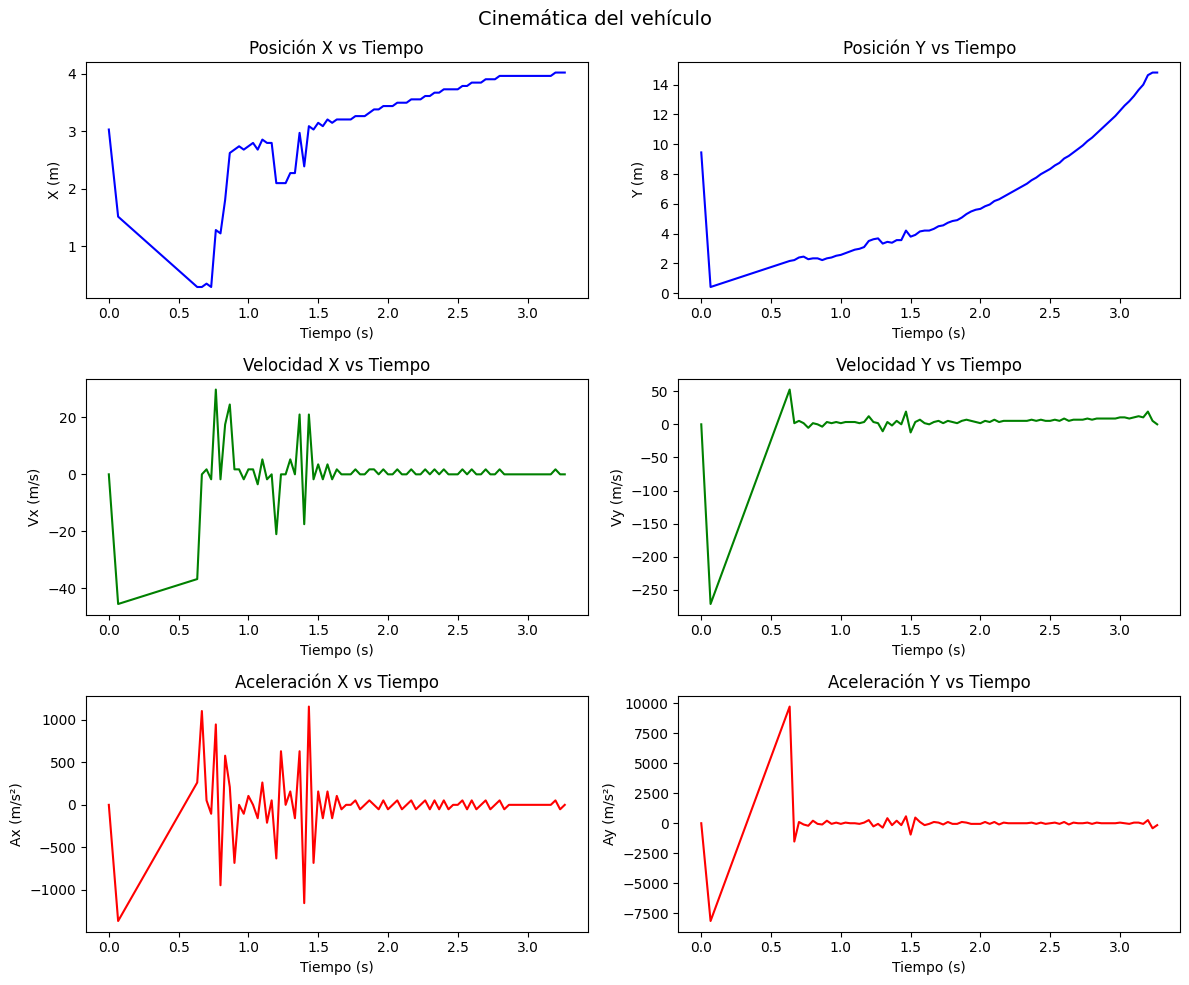

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

cap = cv2.VideoCapture('video.mp4')
sustractor = cv2.createBackgroundSubtractorMOG2(history=500, varThreshold=50, detectShadows=False)
kernel = np.ones((5, 5), np.uint8)
kernel_dilate = np.ones((15, 15), np.uint8)

gris_min  = 180
gris_max  = 255
contraste = 1.2
brillo    = 0
gamma     = 3.0
tabla_gamma = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)

# Escala y tiempo
FPS    = 30
dt     = 1 / FPS
escala = 3.5 / 60  # metros por pixel

# Listas para graficar al final
tiempos       = []
posiciones_x  = []
posiciones_y  = []
velocidades_x = []
velocidades_y = []
acel_x        = []
acel_y        = []

frame_num = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gris = np.clip((gris - gris_min) * (255 / (gris_max - gris_min)), 0, 255).astype(np.uint8)
    gris = cv2.convertScaleAbs(gris, alpha=contraste, beta=brillo)
    gris = cv2.LUT(gris, tabla_gamma)

    mascara = sustractor.apply(gris)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel)
    mascara = cv2.dilate(mascara, kernel_dilate, iterations=1)
    mascara = mascara[145:471, 355:461]

    contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    visualizacion = cv2.cvtColor(mascara, cv2.COLOR_GRAY2BGR)

    if len(contornos) >= 2:
        dos_mayores   = sorted(contornos, key=cv2.contourArea, reverse=True)[:2]
        puntos_unidos = np.vstack(dos_mayores)
        contorno_final = cv2.convexHull(puntos_unidos)
    elif len(contornos) == 1:
        contorno_final = cv2.convexHull(contornos[0])
    else:
        contorno_final = None

    if contorno_final is not None:
        cv2.drawContours(visualizacion, [contorno_final], -1, (0, 255, 0), 2)

        M = cv2.moments(contorno_final)
        if M['m00'] != 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])

            t = frame_num * dt
            tiempos.append(t)
            posiciones_x.append(cx * escala)
            posiciones_y.append(cy * escala)

            # Velocidad por diferencias finitas hacia adelante
            if len(posiciones_x) >= 2:
                vx = (posiciones_x[-1] - posiciones_x[-2]) / dt
                vy = (posiciones_y[-1] - posiciones_y[-2]) / dt
            else:
                vx, vy = 0.0, 0.0
            velocidades_x.append(vx)
            velocidades_y.append(vy)

            # Aceleración como segunda derivada
            if len(velocidades_x) >= 2:
                ax_ = (velocidades_x[-1] - velocidades_x[-2]) / dt
                ay_ = (velocidades_y[-1] - velocidades_y[-2]) / dt
            else:
                ax_, ay_ = 0.0, 0.0
            acel_x.append(ax_)
            acel_y.append(ay_)

            # Velocidad instantánea en tiempo real
            v_inst = np.sqrt(vx**2 + vy**2)
            cv2.circle(visualizacion, (cx, cy), 5, (0, 0, 255), -1)
            cv2.putText(visualizacion, f'{v_inst:.2f} m/s', (cx + 8, cy),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)
            #print(f"Frame {frame_num:04d} | Vel: {v_inst:.4f} m/s | Ax: {ax_:.4f} m/s² | Ay: {ay_:.4f} m/s²")
    cv2.imshow('Contorno y Velocidad', visualizacion)
    frame_num += 1

    if cv2.waitKey(25) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

# Graficas al final
fig, axs = plt.subplots(3, 2, figsize=(12, 10))
fig.suptitle('Cinemática del vehículo', fontsize=14)

axs[0, 0].plot(tiempos, posiciones_x, color='blue')
axs[0, 0].set_title('Posición X vs Tiempo')
axs[0, 0].set_xlabel('Tiempo (s)')
axs[0, 0].set_ylabel('X (m)')

axs[0, 1].plot(tiempos, posiciones_y, color='blue')
axs[0, 1].set_title('Posición Y vs Tiempo')
axs[0, 1].set_xlabel('Tiempo (s)')
axs[0, 1].set_ylabel('Y (m)')

axs[1, 0].plot(tiempos, velocidades_x, color='green')
axs[1, 0].set_title('Velocidad X vs Tiempo')
axs[1, 0].set_xlabel('Tiempo (s)')
axs[1, 0].set_ylabel('Vx (m/s)')

axs[1, 1].plot(tiempos, velocidades_y, color='green')
axs[1, 1].set_title('Velocidad Y vs Tiempo')
axs[1, 1].set_xlabel('Tiempo (s)')
axs[1, 1].set_ylabel('Vy (m/s)')

axs[2, 0].plot(tiempos, acel_x, color='red')
axs[2, 0].set_title('Aceleración X vs Tiempo')
axs[2, 0].set_xlabel('Tiempo (s)')
axs[2, 0].set_ylabel('Ax (m/s²)')

axs[2, 1].plot(tiempos, acel_y, color='red')
axs[2, 1].set_title('Aceleración Y vs Tiempo')
axs[2, 1].set_xlabel('Tiempo (s)')
axs[2, 1].set_ylabel('Ay (m/s²)')

plt.tight_layout()
plt.show()

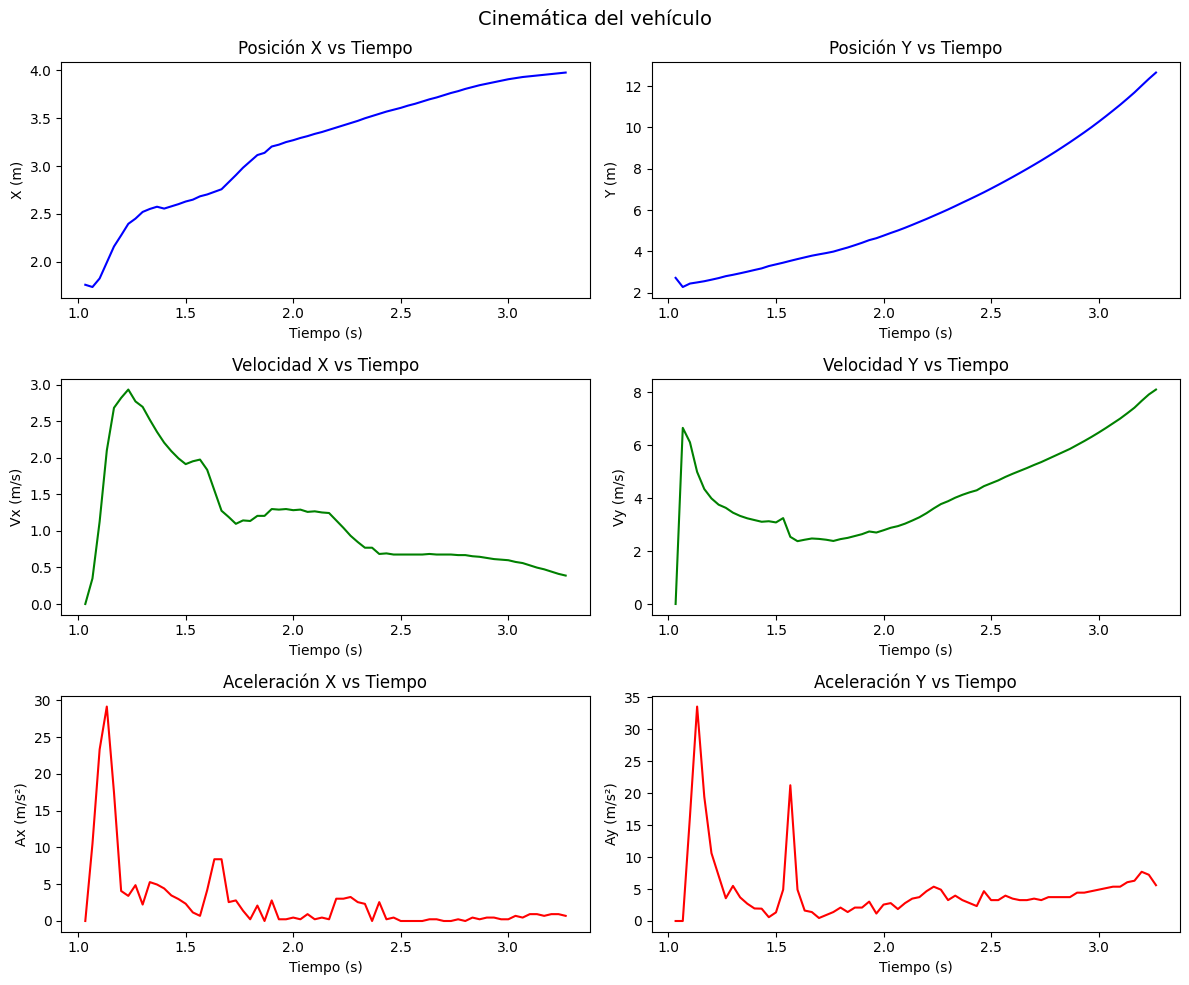

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

cap = cv2.VideoCapture('video.mp4')
sustractor = cv2.createBackgroundSubtractorMOG2(history=500, varThreshold=50, detectShadows=False)
kernel = np.ones((5, 5), np.uint8)
kernel_dilate = np.ones((15, 15), np.uint8)

gris_min  = 180
gris_max  = 255
contraste = 1.2
brillo    = 0
gamma     = 3.0
tabla_gamma = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)

FPS    = 30
dt     = 1 / FPS
escala = 3.5 / 60

VEL_MAX      = 15.0  # m/s — ajusta según la velocidad real del vehículo
VENTANA_SUAV = 15    # frames para media móvil

buffer_x  = deque(maxlen=VENTANA_SUAV)
buffer_y  = deque(maxlen=VENTANA_SUAV)
buffer_vx = deque(maxlen=VENTANA_SUAV)  # media móvil también en velocidad
buffer_vy = deque(maxlen=VENTANA_SUAV)

tiempos       = []
posiciones_x  = []
posiciones_y  = []
velocidades_x = []
velocidades_y = []
acel_x        = []
acel_y        = []

frame_num = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gris = np.clip((gris - gris_min) * (255 / (gris_max - gris_min)), 0, 255).astype(np.uint8)
    gris = cv2.convertScaleAbs(gris, alpha=contraste, beta=brillo)
    gris = cv2.LUT(gris, tabla_gamma)

    mascara = sustractor.apply(gris)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel)
    mascara = cv2.dilate(mascara, kernel_dilate, iterations=1)
    mascara = mascara[145:471, 355:461]

    contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    visualizacion = cv2.cvtColor(mascara, cv2.COLOR_GRAY2BGR)

    if len(contornos) >= 2:
        dos_mayores    = sorted(contornos, key=cv2.contourArea, reverse=True)[:2]
        puntos_unidos  = np.vstack(dos_mayores)
        contorno_final = cv2.convexHull(puntos_unidos)
    elif len(contornos) == 1:
        contorno_final = cv2.convexHull(contornos[0])
    else:
        contorno_final = None

    if contorno_final is not None:
        cv2.drawContours(visualizacion, [contorno_final], -1, (0, 255, 0), 2)

        M = cv2.moments(contorno_final)
        if M['m00'] != 0:
            cx_raw = int(M['m10'] / M['m00'])
            cy_raw = int(M['m01'] / M['m00'])

            buffer_x.append(cx_raw * escala)
            buffer_y.append(cy_raw * escala)

            # Esperar a que el buffer esté lleno antes de calcular
            if len(buffer_x) < VENTANA_SUAV:
                frame_num += 1
                cv2.imshow('Contorno y Velocidad', visualizacion)
                if cv2.waitKey(25) & 0xFF == 27:
                    break
                continue

            cx_suav = np.mean(buffer_x)
            cy_suav = np.mean(buffer_y)

            tiempos.append(frame_num * dt)
            posiciones_x.append(cx_suav)
            posiciones_y.append(cy_suav)

            # Velocidad
            if len(posiciones_x) >= 2:
                vx_raw = abs((posiciones_x[-1] - posiciones_x[-2]) / dt)
                vy_raw = abs((posiciones_y[-1] - posiciones_y[-2]) / dt)
            else:
                vx_raw, vy_raw = 0.0, 0.0

            v_raw = np.sqrt(vx_raw*2 + vy_raw*2)  # corregido
            if v_raw > VEL_MAX and len(buffer_vx) > 0:
                vx_raw = buffer_vx[-1]
                vy_raw = buffer_vy[-1]

            buffer_vx.append(vx_raw)
            buffer_vy.append(vy_raw)
            vx = np.mean(buffer_vx)
            vy = np.mean(buffer_vy)
            v_inst = np.sqrt(vx*2 + vy*2)  # corregido

            velocidades_x.append(vx)
            velocidades_y.append(vy)

            # Aceleración con filtro de valor atípico
            ACEL_MAX = 50.0  # m/s² — ajusta si es necesario
            if len(velocidades_x) >= 2:
                ax_ = abs((velocidades_x[-1] - velocidades_x[-2]) / dt)
                ay_ = abs((velocidades_y[-1] - velocidades_y[-2]) / dt)
                # Filtro de aceleración atípica
                if len(acel_x) > 0:
                    if ax_ > ACEL_MAX:
                        ax_ = acel_x[-1]
                    if ay_ > ACEL_MAX:
                        ay_ = acel_y[-1]
            else:
                ax_, ay_ = 0.0, 0.0
            acel_x.append(ax_)
            acel_y.append(ay_)

            cv2.circle(visualizacion, (cx_raw, cy_raw), 5, (0, 0, 255), -1)
            cv2.putText(visualizacion, f'{v_inst:.2f} m/s', (cx_raw + 8, cy_raw),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)

            #print(f"Frame {frame_num:04d} | Vel: {v_inst:.4f} m/s | Ax: {ax_:.4f} m/s² | Ay: {ay_:.4f} m/s²")

    cv2.imshow('Contorno y Velocidad', visualizacion)
    frame_num += 1

    if cv2.waitKey(25) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

# Gráficas al final
fig, axs = plt.subplots(3, 2, figsize=(12, 10))
fig.suptitle('Cinemática del vehículo', fontsize=14)

axs[0, 0].plot(tiempos, posiciones_x, color='blue')
axs[0, 0].set_title('Posición X vs Tiempo')
axs[0, 0].set_xlabel('Tiempo (s)')
axs[0, 0].set_ylabel('X (m)')

axs[0, 1].plot(tiempos, posiciones_y, color='blue')
axs[0, 1].set_title('Posición Y vs Tiempo')
axs[0, 1].set_xlabel('Tiempo (s)')
axs[0, 1].set_ylabel('Y (m)')

axs[1, 0].plot(tiempos, velocidades_x, color='green')
axs[1, 0].set_title('Velocidad X vs Tiempo')
axs[1, 0].set_xlabel('Tiempo (s)')
axs[1, 0].set_ylabel('Vx (m/s)')

axs[1, 1].plot(tiempos, velocidades_y, color='green')
axs[1, 1].set_title('Velocidad Y vs Tiempo')
axs[1, 1].set_xlabel('Tiempo (s)')
axs[1, 1].set_ylabel('Vy (m/s)')

axs[2, 0].plot(tiempos, acel_x, color='red')
axs[2, 0].set_title('Aceleración X vs Tiempo')
axs[2, 0].set_xlabel('Tiempo (s)')
axs[2, 0].set_ylabel('Ax (m/s²)')

axs[2, 1].plot(tiempos, acel_y, color='red')
axs[2, 1].set_title('Aceleración Y vs Tiempo')
axs[2, 1].set_xlabel('Tiempo (s)')
axs[2, 1].set_ylabel('Ay (m/s²)')

plt.tight_layout()
plt.show()